In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings as wn

wn.filterwarnings('ignore')


In [32]:
df = pd.read_csv('ObesityDataSet_raw.csv')

In [33]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# EDA (Exploratory Data Analysis)

In [34]:
df.shape

(2111, 17)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [36]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [37]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObesity                          0
dtype: int64

In [38]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObesity'],
      dtype='object')

In [39]:
print(df['NObesity'].value_counts())


NObesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


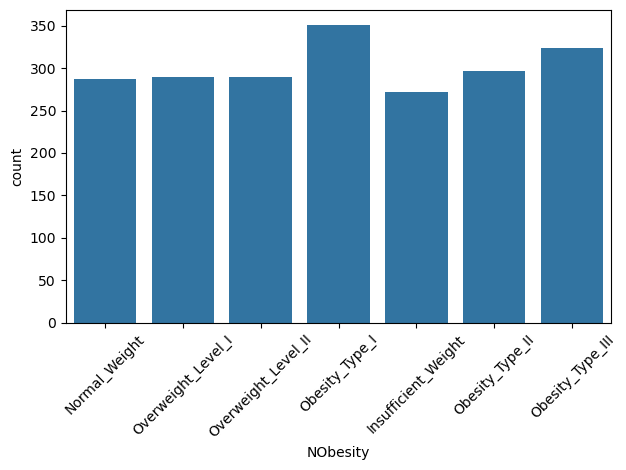

In [40]:
sns.countplot(x='NObesity', data=df)
plt.xticks(rotation=45)
plt.tight_layout()

Obese vs Not obese

<Axes: xlabel='obese', ylabel='count'>

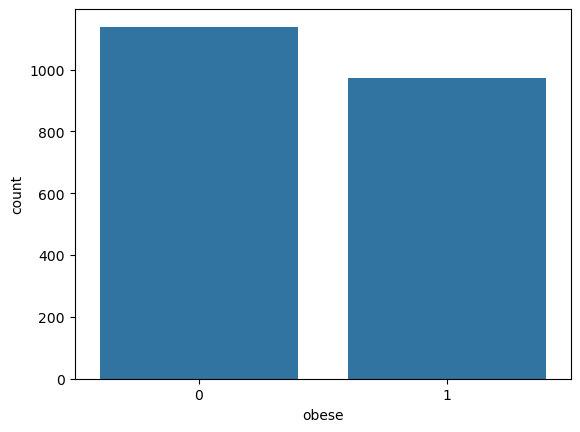

In [41]:
obese_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
df['obese'] = df['NObesity'].apply(lambda x: 1 if x in obese_classes else 0)
sns.countplot(x='obese', data=df)

Numeric feature distributions

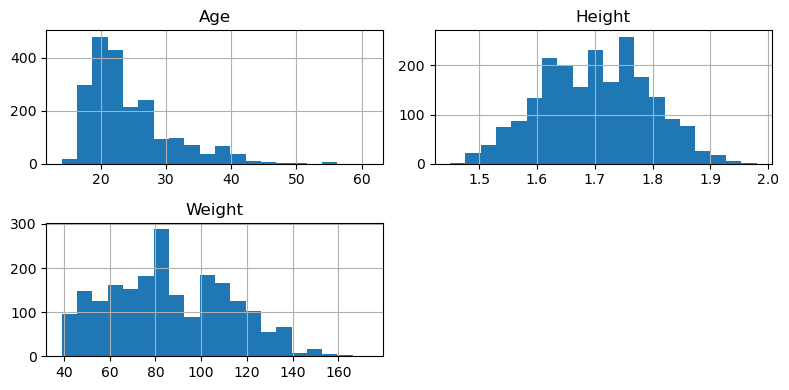

In [42]:
num_cols = ['Age', 'Height', 'Weight']
df[num_cols].hist(bins=20, figsize=(8,4))
plt.tight_layout()

Correlation heatmap

<Axes: >

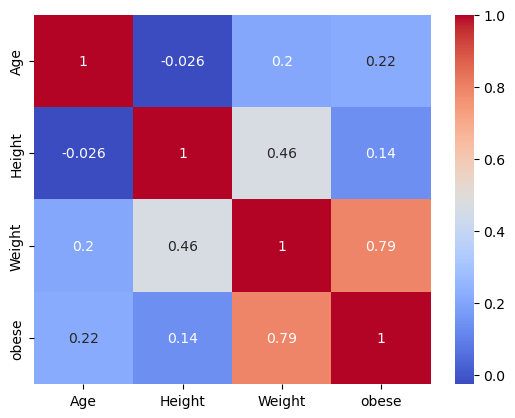

In [43]:
corr = df[num_cols + ['obese']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')


Categorical feature analysis

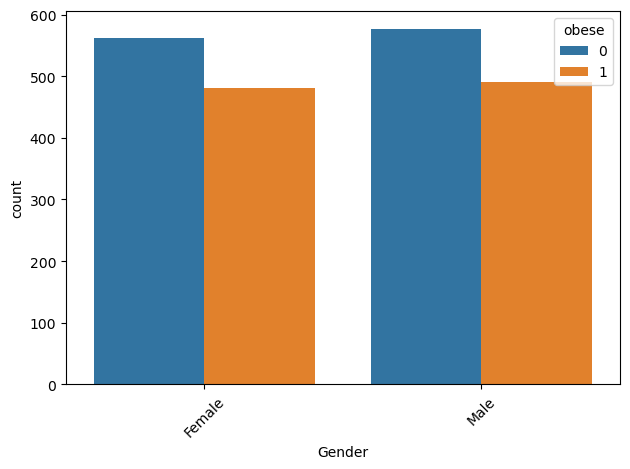

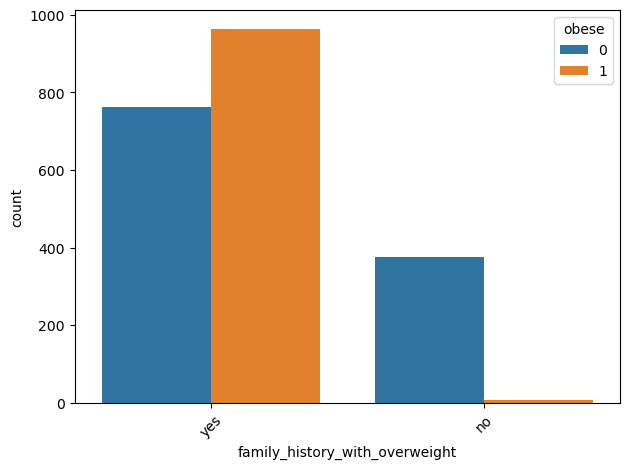

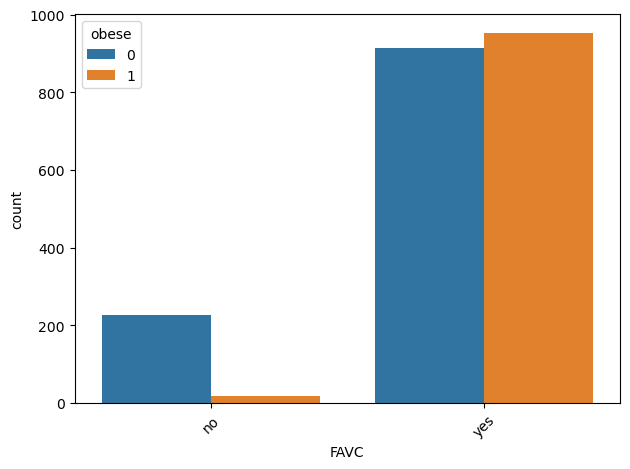

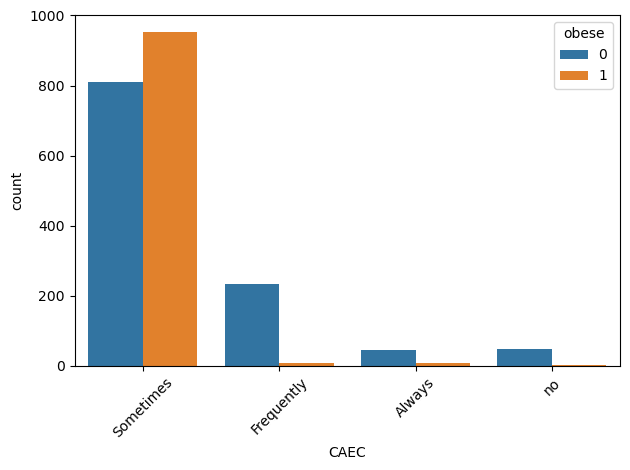

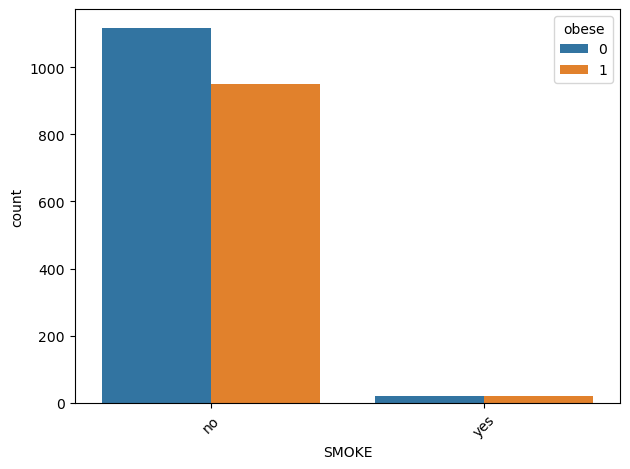

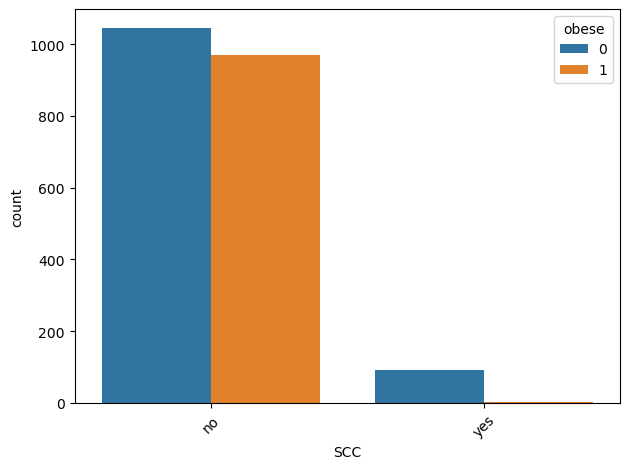

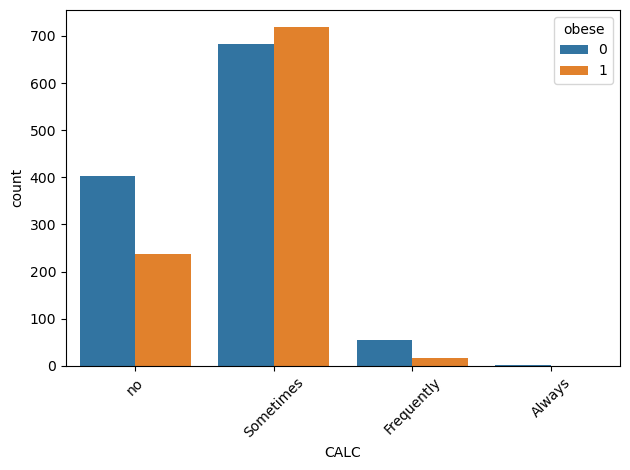

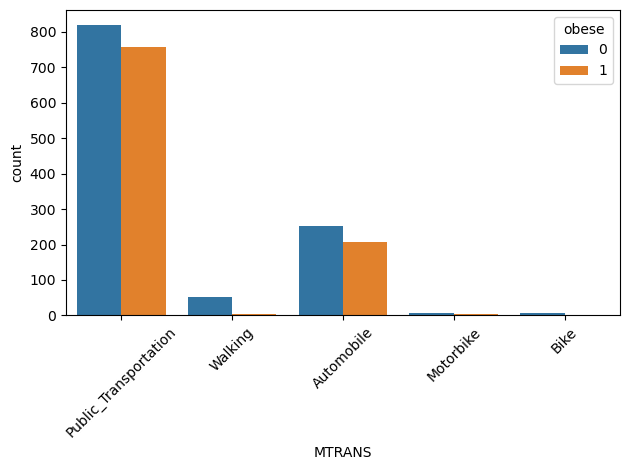

In [44]:
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c not in ['NObesity']]
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue='obese', data=df)
    plt.xticks(rotation=45)
    plt.tight_layout()


Train–test split and preprocessing

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=['NObesity', 'obese'])
y = df['obese']

num_features = ['Age', 'Height', 'Weight']
cat_features = [c for c in X.columns if c not in num_features]

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM_linear": SVC(kernel="linear", probability=True),
    "SVM_rbf": SVC(kernel="rbf", probability=True),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess),
                           ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append((name, acc, f1))

for r in results:
    print(r)


('LogisticRegression', 0.9905437352245863, 0.9897435897435898)
('KNN', 0.950354609929078, 0.9454545454545454)
('SVM_linear', 0.9881796690307328, 0.9872122762148338)
('SVM_rbf', 0.9929078014184397, 0.9922879177377892)
('DecisionTree', 0.9858156028368794, 0.9846153846153847)
('RandomForest', 0.966903073286052, 0.9635416666666666)
('GradientBoosting', 0.9905437352245863, 0.9897435897435898)


In [62]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import pickle

best_clf = SVC(kernel="rbf", probability=True)

best_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", best_clf),
])

best_pipe.fit(X_train, y_train)

with open("best_obesity_model.pkl", "wb") as f:
    pickle.dump(best_pipe, f)
